In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, isnan, when, count
import math
from sklearn.metrics import classification_report
from pyspark.ml.evaluation import MulticlassClassificationEvaluator



### Initialize Spark session


In [2]:

spark = SparkSession.builder.appName("HeartAttackPrediction").getOrCreate()


### Load dataset


In [3]:

data = spark.read.csv('augmented_data.csv', header=True, inferSchema=True)
data.printSchema()


root
 |-- _c0: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- chestpaintype: integer (nullable = true)
 |-- restingBP: integer (nullable = true)
 |-- cholestrol: integer (nullable = true)
 |-- fastingbloodsugar: integer (nullable = true)
 |-- restingECG: integer (nullable = true)
 |-- maxheartrate: integer (nullable = true)
 |-- exerciseangia: integer (nullable = true)
 |-- oldpeak: double (nullable = true)
 |-- slope: integer (nullable = true)
 |-- target: integer (nullable = true)



In [4]:
data.show(5)

+---+---+------+-------------+---------+----------+-----------------+----------+------------+-------------+------------------+-----+------+
|_c0|age|gender|chestpaintype|restingBP|cholestrol|fastingbloodsugar|restingECG|maxheartrate|exerciseangia|           oldpeak|slope|target|
+---+---+------+-------------+---------+----------+-----------------+----------+------------+-------------+------------------+-----+------+
|  0| 46|     0|            2|      159|       344|                0|         1|         151|            0|2.7712762832641604|    1|     0|
|  1| 59|     0|            2|      151|       217|                0|         1|         128|            1|0.2818498611450195|    1|     0|
|  3| 57|     1|            2|      118|       233|                0|         0|         120|            0|0.9896656036376954|    1|     0|
|  6| 51|     0|            2|      142|       275|                0|         1|         138|            0|1.4456494331359866|    1|     0|
|  8| 52|     0|    

##### Check for Missing Values


In [5]:
data.select([count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in data.columns]).show()

+---+---+------+-------------+---------+----------+-----------------+----------+------------+-------------+-------+-----+------+
|_c0|age|gender|chestpaintype|restingBP|cholestrol|fastingbloodsugar|restingECG|maxheartrate|exerciseangia|oldpeak|slope|target|
+---+---+------+-------------+---------+----------+-----------------+----------+------------+-------------+-------+-----+------+
|  0|  0|     0|            0|        0|         0|                0|         0|           0|            0|      0|    0|     0|
+---+---+------+-------------+---------+----------+-----------------+----------+------------+-------------+-------+-----+------+



##### Summary Statistics


In [ ]:
data.describe().show()


In [ ]:
data.count()

2400000

In [ ]:
data.dropDuplicates()

DataFrame[_c0: int, age: int, gender: int, chestpaintype: int, restingBP: int, cholestrol: int, fastingbloodsugar: int, restingECG: int, maxheartrate: int, exerciseangia: int, oldpeak: double, slope: int, target: int]

In [ ]:
data.count()

2400000

## EDA


In [ ]:
columns = [
    'age', 'gender', 'chestpaintype', 'restingBP', 'cholestrol',
    'fastingbloodsugar', 'restingECG', 'maxheartrate',
    'exerciseangia', 'oldpeak', 'slope', 'target'
]


In [ ]:
df_sample = data.limit(10000).toPandas()
sns.set(style="whitegrid")

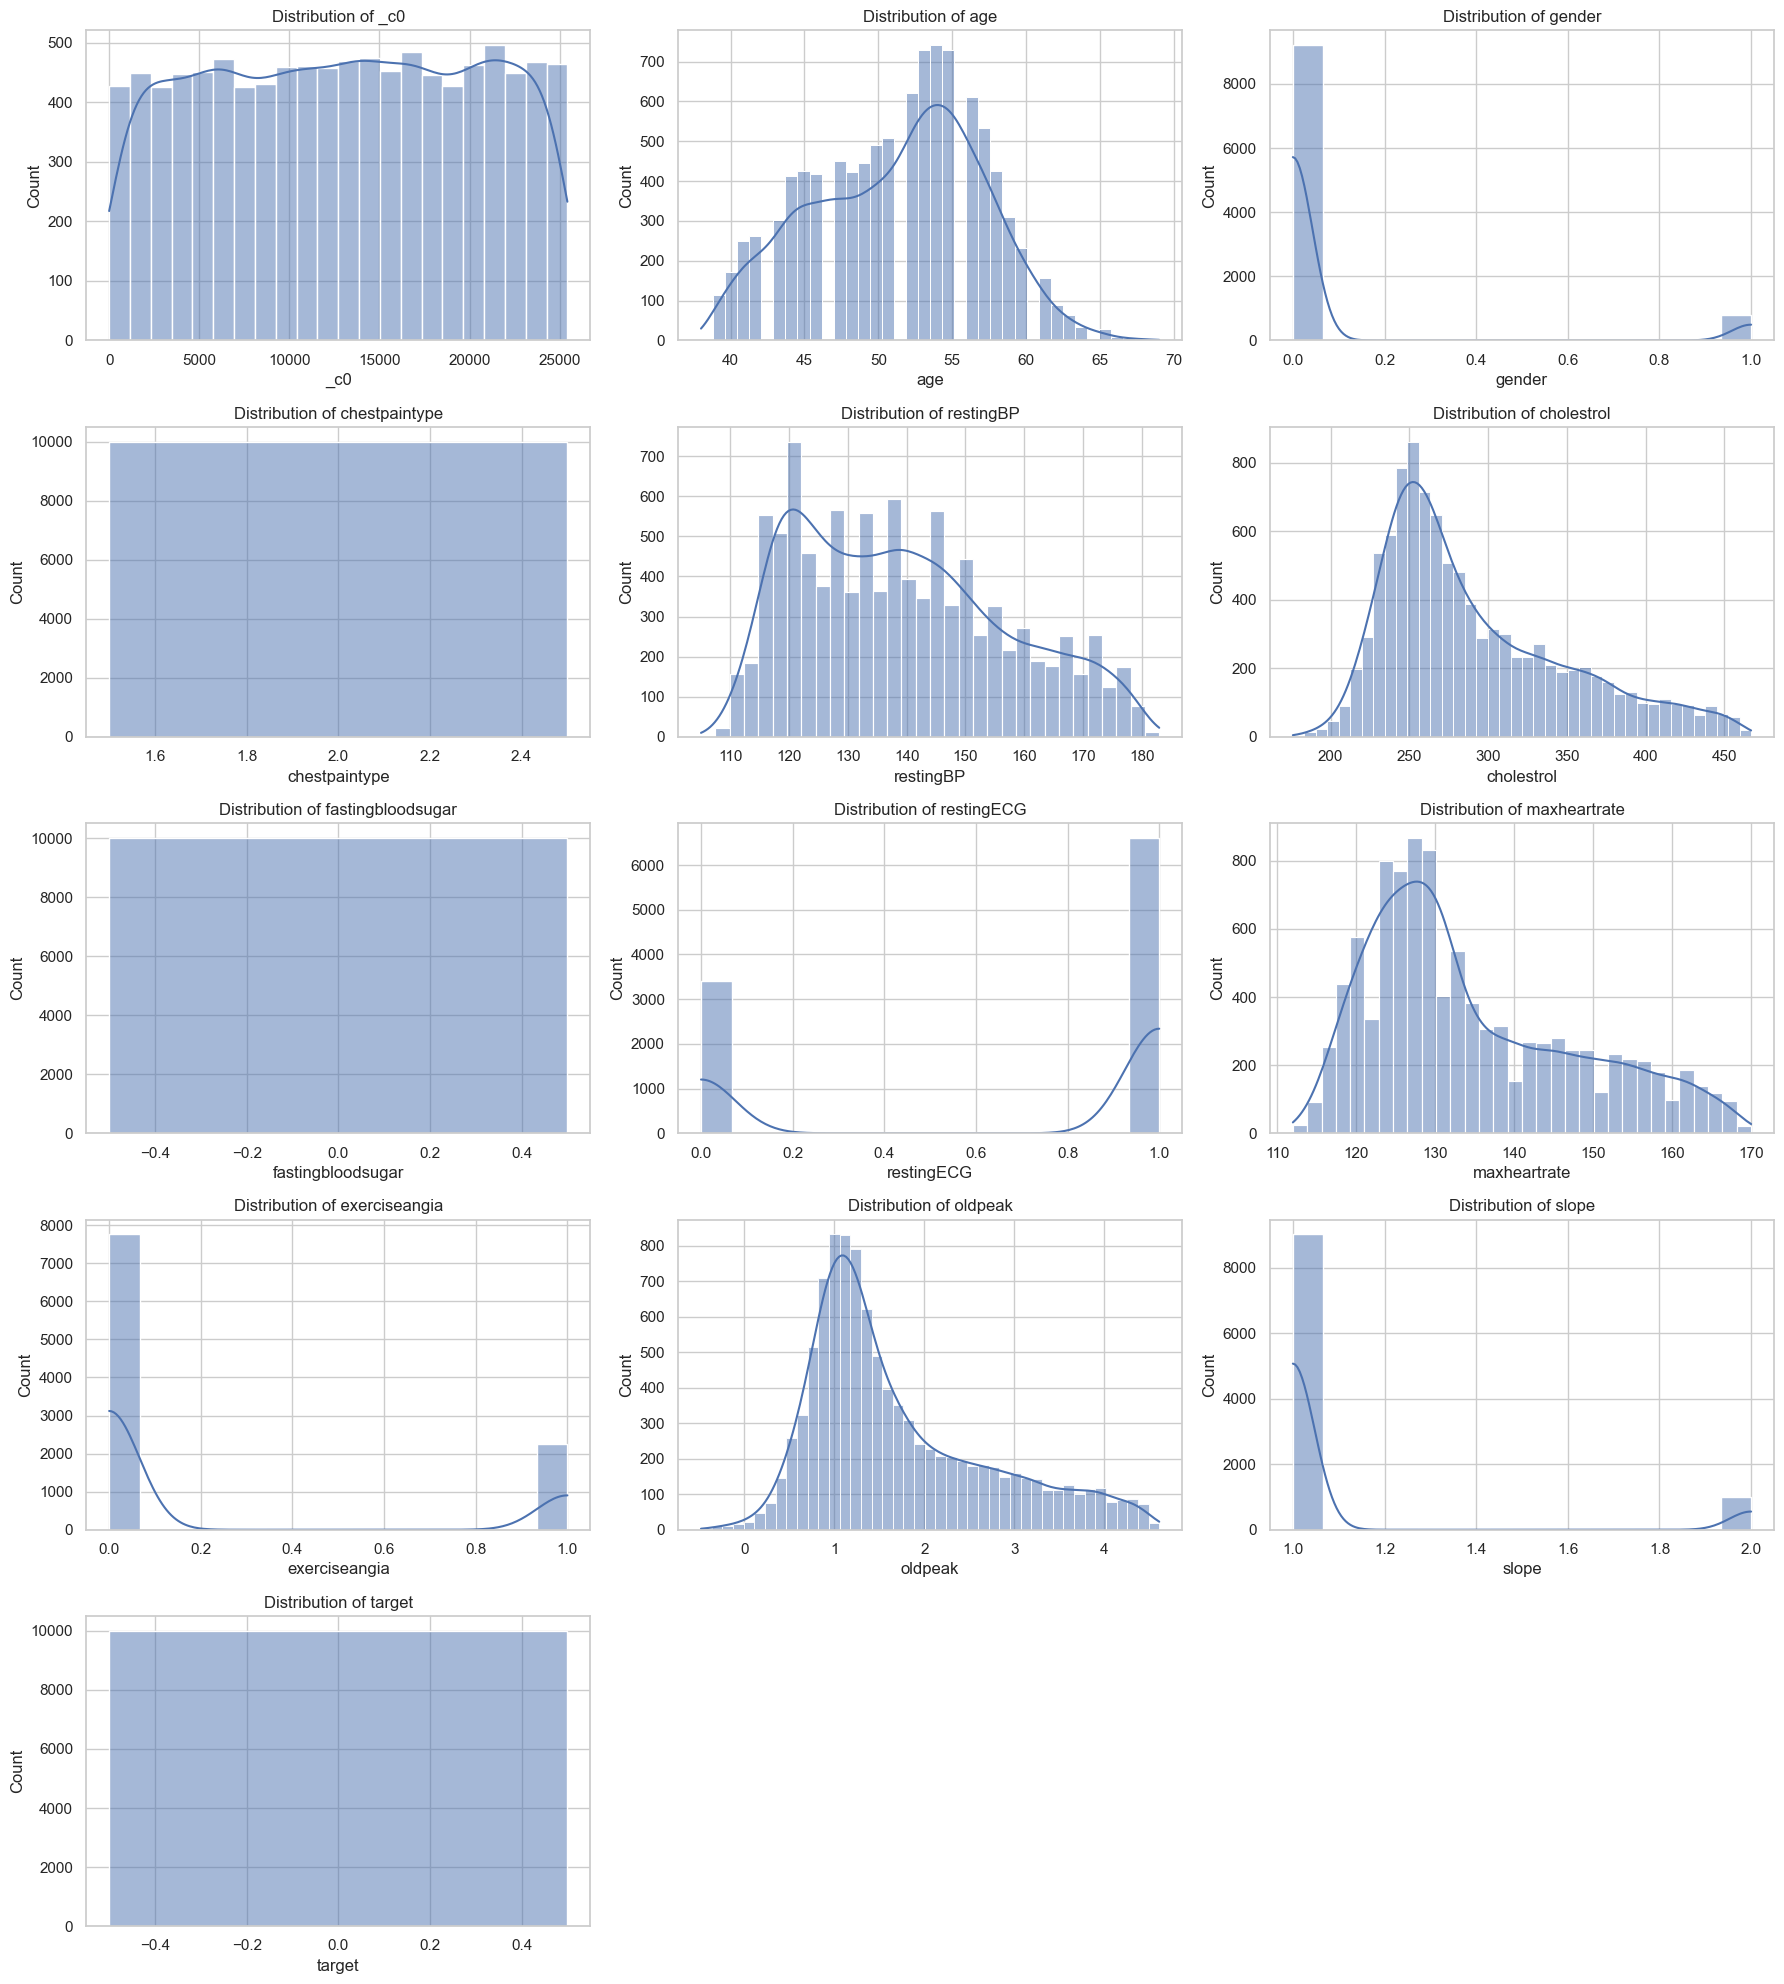

In [ ]:
num_cols = len(df_sample.columns)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()

for i, colmn in enumerate(df_sample.columns):
    sns.histplot(df_sample[colmn], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {colmn}')
    axes[i].set_xlabel(colmn)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Handling Outliers


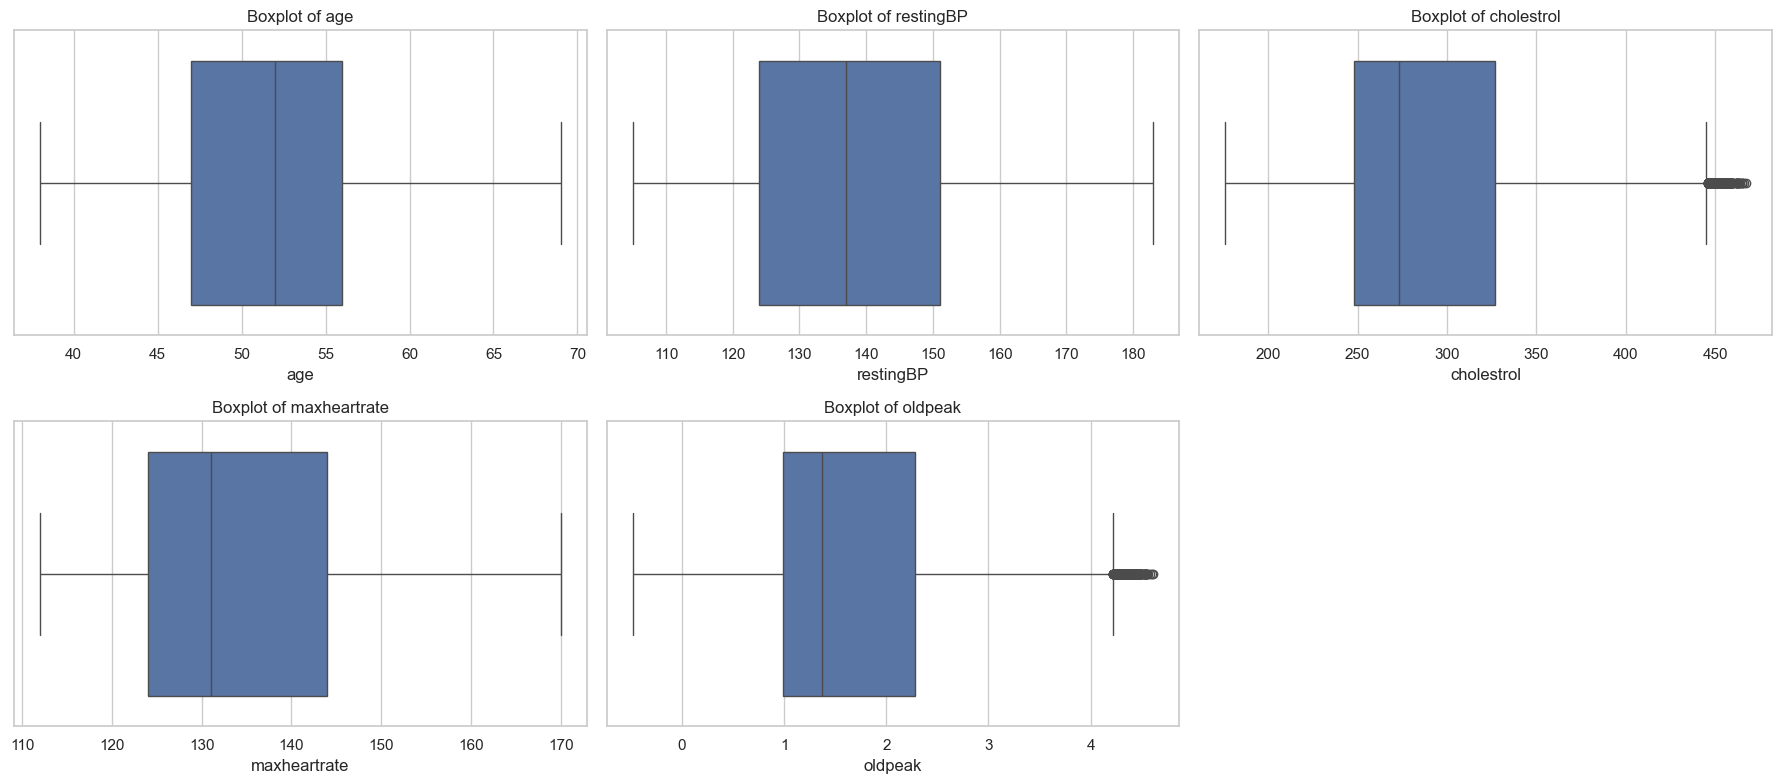

In [ ]:
boxplot_columns = ['age', 'restingBP', 'cholestrol', 'maxheartrate', 'oldpeak']
num_cols = len(boxplot_columns)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
axes = axes.flatten()

for i, column in enumerate(boxplot_columns):
    sns.boxplot(x=df_sample[column], ax=axes[i])
    axes[i].set_title(f'Boxplot of {column}')
    axes[i].set_xlabel(column)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
df_filtered = data

for feature in boxplot_columns: 
    q1, q3 = df_filtered.approxQuantile(feature, [0.25, 0.75], 0.05)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    print(f"{feature}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, Lower={lower:.2f}, Upper={upper:.2f}")
    df_filtered = df_filtered.filter((col(feature) >= lower) & (col(feature) <= upper))

age: Q1=45.00, Q3=56.00, IQR=11.00, Lower=28.50, Upper=72.50
restingBP: Q1=123.00, Q3=157.00, IQR=34.00, Lower=72.00, Upper=208.00
cholestrol: Q1=255.00, Q3=357.00, IQR=102.00, Lower=102.00, Upper=510.00
maxheartrate: Q1=123.00, Q3=150.00, IQR=27.00, Lower=82.50, Upper=190.50
oldpeak: Q1=1.10, Q3=2.47, IQR=1.38, Lower=-0.97, Upper=4.54


In [ ]:
print(f"Rows after outlier removal: {df_filtered.count()}")

Rows after outlier removal: 2257067


#### Heatmap Correlation


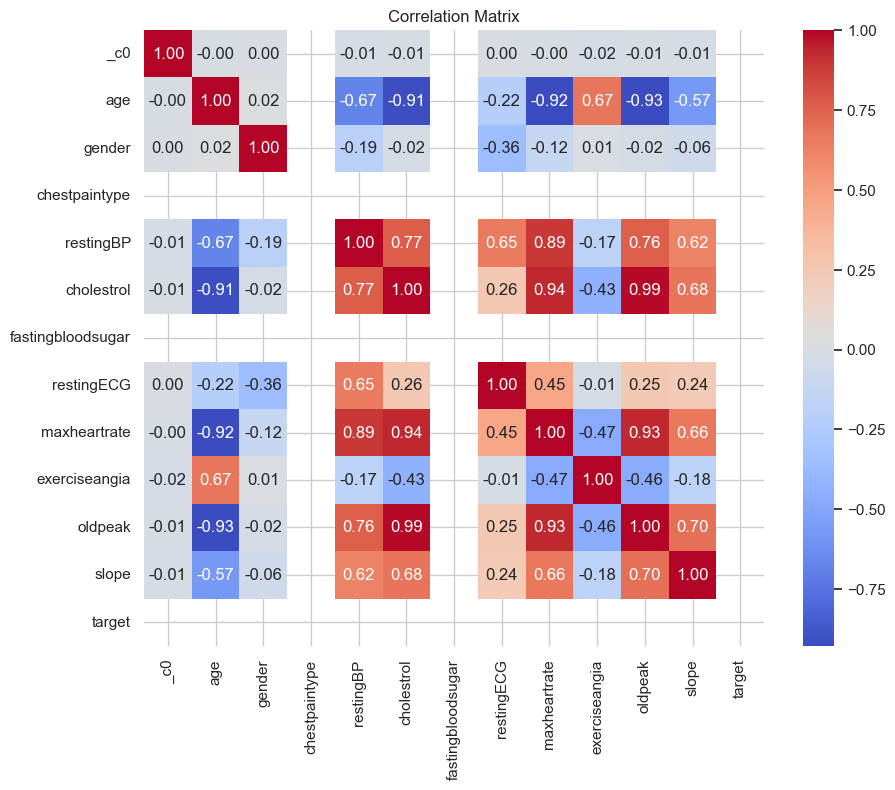

In [ ]:
plt.figure(figsize=(10, 8))
corr = df_sample.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


##### Class distribution


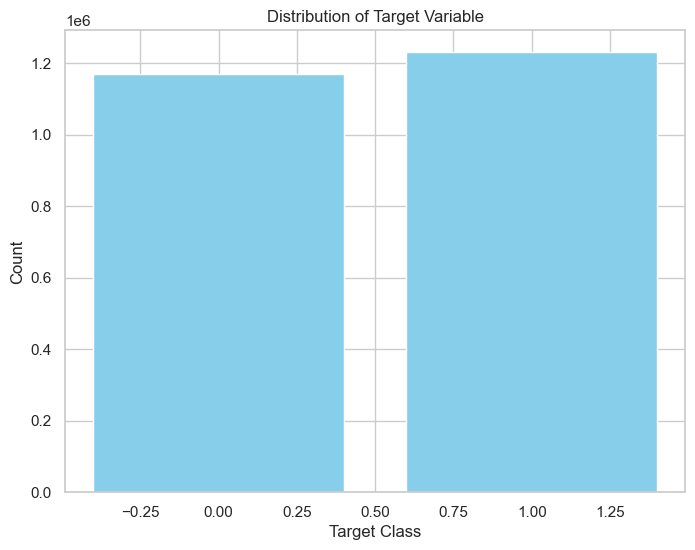

In [ ]:
target_dist = data.groupBy("target").count().toPandas()

plt.figure(figsize=(8, 6))
plt.bar(target_dist['target'], target_dist['count'], color='skyblue')
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.title("Distribution of Target Variable")
plt.show()


In [ ]:
data.groupBy("target").count().show()

+------+-------+
|target|  count|
+------+-------+
|     1|1230653|
|     0|1169347|
+------+-------+



### Feature engineering


In [ ]:

assembler = VectorAssembler(inputCols=columns[:-1], outputCol="features")
df = assembler.transform(data)


### Split data and Initialize Random Forest model


In [ ]:

train, test = df.randomSplit([0.8, 0.2], seed=1234)

rf = RandomForestClassifier(labelCol="target", featuresCol="features", seed=1234)


### Cross-validation


In [ ]:

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [5, 10, 15]) \
    .build()

crossval = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=MulticlassClassificationEvaluator(labelCol="target", metricName="accuracy"),
    numFolds=3
)


### Train model


In [ ]:

cvModel = crossval.fit(train)

### Evaluate model


In [ ]:
predictions = cvModel.transform(test)
evaluator = MulticlassClassificationEvaluator(labelCol="target", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9615162037037037


### Confusion matrix


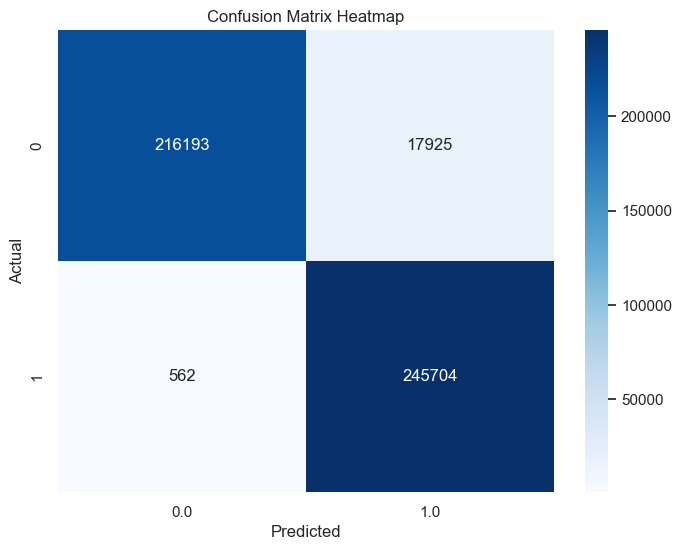

In [ ]:

confusion_matrix_data = predictions.groupBy("target", "prediction").count().toPandas()
confusion_matrix = confusion_matrix_data.pivot(index="target", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=True, yticklabels=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Classification Report

In [ ]:

y_true = predictions.select("target").rdd.flatMap(lambda x: x).collect()
y_pred = predictions.select("prediction").rdd.flatMap(lambda x: x).collect()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, digits=4))


Classification Report:

              precision    recall  f1-score   support

           0     0.9974    0.9234    0.9590    234118
           1     0.9320    0.9977    0.9637    246266

    accuracy                         0.9615    480384
   macro avg     0.9647    0.9606    0.9614    480384
weighted avg     0.9639    0.9615    0.9614    480384



### Save model


In [ ]:

cvModel.bestModel.write().overwrite().save("random_forest_model")